In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

bitcoin = pd.read_csv('bitcoin_features.csv')
bitcoin['date'] = pd.to_datetime(bitcoin['date'])
bitcoin = bitcoin.set_index('date')

print("✅ Data Loaded!")
print("Shape:", bitcoin.shape)

✅ Data Loaded!
Shape: (3012, 33)


In [2]:
## Feature Target define
feature_cols = [
    'open', 'high', 'low', 'close', 'volume',
    'MA_7', 'MA_14', 'MA_30',
    'price_range', 'price_range_pct', 'close_open_pct',
    'BB_width', 'ATR_14',
    'volume_MA7', 'volume_change', 'volume_spike',
    'liquidity_ratio',
    'volatility_lag1', 'volatility_lag3', 'volatility_lag7',
    'return_lag1', 'return_lag3',
    'RSI_14'
]

X = bitcoin[feature_cols]
y = bitcoin['volatility_7d']

print("✅ Features:", X.shape)
print("✅ Target:", y.shape)

✅ Features: (3012, 23)
✅ Target: (3012,)


In [3]:
## Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (2409, 23)
Test size: (603, 23)


In [4]:
X_train.dtypes

open               float64
high               float64
low                float64
close              float64
volume             float64
MA_7               float64
MA_14              float64
MA_30              float64
price_range        float64
price_range_pct    float64
close_open_pct     float64
BB_width           float64
ATR_14             float64
volume_MA7         float64
volume_change      float64
volume_spike       float64
liquidity_ratio    float64
volatility_lag1    float64
volatility_lag3    float64
volatility_lag7    float64
return_lag1        float64
return_lag3        float64
RSI_14             float64
dtype: object

In [5]:
print("NaN count:", np.isnan(X_train).sum())
print("Inf count:", np.isinf(X_train).sum())

NaN count: open               0
high               0
low                0
close              0
volume             0
MA_7               0
MA_14              0
MA_30              0
price_range        0
price_range_pct    0
close_open_pct     0
BB_width           0
ATR_14             0
volume_MA7         0
volume_change      0
volume_spike       0
liquidity_ratio    0
volatility_lag1    0
volatility_lag3    0
volatility_lag7    0
return_lag1        0
return_lag3        0
RSI_14             0
dtype: int64
Inf count: open               0
high               0
low                0
close              0
volume             0
MA_7               0
MA_14              0
MA_30              0
price_range        0
price_range_pct    0
close_open_pct     0
BB_width           0
ATR_14             0
volume_MA7         0
volume_change      1
volume_spike       0
liquidity_ratio    0
volatility_lag1    0
volatility_lag3    0
volatility_lag7    0
return_lag1        0
return_lag3        0
RSI_14             0

In [6]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

In [7]:
print(X_train.columns.equals(X_test.columns))

True


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Scaling Done!")

✅ Scaling Done!


In [9]:
## Random Forest Model
rf_model = RandomForestRegressor(
    n_estimators=100, 
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

# Evaluation
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_r2   = r2_score(y_test, rf_pred)

print("=== Random Forest Results ===")
print(f"RMSE: {rf_rmse:.6f}")
print(f"MAE:  {rf_mae:.6f}")
print(f"R²:   {rf_r2:.4f}")

=== Random Forest Results ===
RMSE: 0.007467
MAE:  0.005019
R²:   0.8046


In [10]:
## Xg Boost Model
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)

# Evaluation
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_r2   = r2_score(y_test, xgb_pred)

print("=== XGBoost Results ===")
print(f"RMSE: {xgb_rmse:.6f}")
print(f"MAE:  {xgb_mae:.6f}")
print(f"R²:   {xgb_r2:.4f}")

=== XGBoost Results ===
RMSE: 0.007201
MAE:  0.004658
R²:   0.8183


In [11]:
## Compare Models
print("=" * 40)
print("      MODEL COMPARISON")
print("=" * 40)
print(f"{'Model':<20} {'RMSE':<12} {'MAE':<12} {'R²'}")
print("-" * 40)
print(f"{'Random Forest':<20} {rf_rmse:<12.6f} {rf_mae:<12.6f} {rf_r2:.4f}")
print(f"{'XGBoost':<20} {xgb_rmse:<12.6f} {xgb_mae:<12.6f} {xgb_r2:.4f}")
print("=" * 40)

      MODEL COMPARISON
Model                RMSE         MAE          R²
----------------------------------------
Random Forest        0.007467     0.005019     0.8046
XGBoost              0.007201     0.004658     0.8183


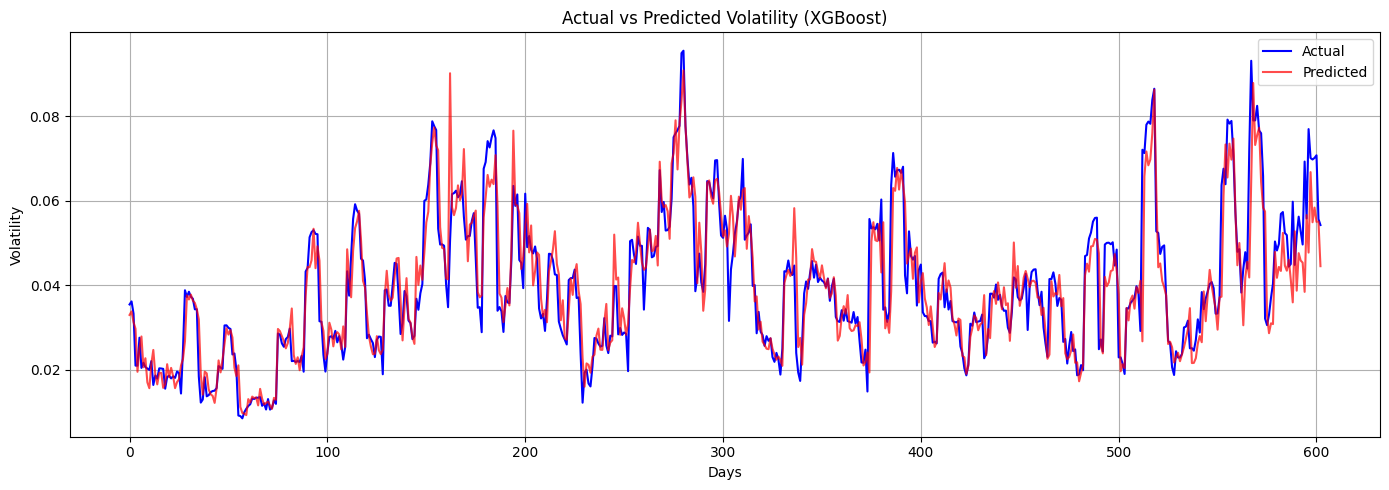

In [12]:
## Best Model Graph
plt.figure(figsize=(14,5))
plt.plot(y_test.values, label='Actual', color='blue')
plt.plot(xgb_pred, label='Predicted', color='red', alpha=0.7)
plt.title('Actual vs Predicted Volatility (XGBoost)')
plt.xlabel('Days')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

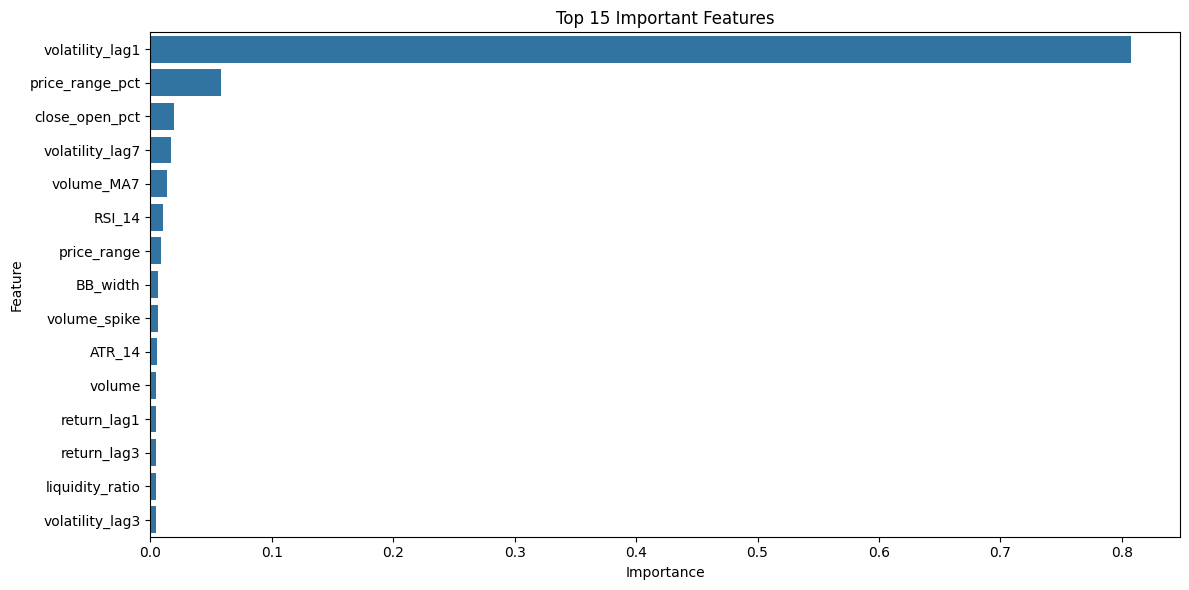

In [13]:
## Feature importance
import seaborn as sns
feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15))
plt.title('Top 15 Important Features')
plt.tight_layout()
plt.show()

In [14]:
## Save Model
import joblib

joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Model Saved!")
print("✅ Scaler Saved!")
print("\n🎉 Step 4 - Model Training Complete!")

✅ Model Saved!
✅ Scaler Saved!

🎉 Step 4 - Model Training Complete!


In [15]:
## Grid Search CV
from sklearn.model_selection import GridSearchCV

print("⏳ Tuning chal raha hai... 2-3 min lagenge!")

params = {
    'n_estimators'    : [100, 200, 300],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'max_depth'       : [3, 5, 7],
    'min_child_weight': [1, 3, 5]
}

grid = GridSearchCV(
    XGBRegressor(random_state=42),
    params,
    cv=5,
    scoring='r2',
    verbose=1
)

grid.fit(X_train_scaled, y_train)

print("\n✅ Tuning Complete!")
print("Best Params:", grid.best_params_)
print("Best R²:", grid.best_score_)

⏳ Tuning chal raha hai... 2-3 min lagenge!
Fitting 5 folds for each of 81 candidates, totalling 405 fits

✅ Tuning Complete!
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 300}
Best R²: 0.9322609981448495


In [16]:
best_model = XGBRegressor(
    n_estimators     = grid.best_params_['n_estimators'],
    learning_rate    = grid.best_params_['learning_rate'],
    max_depth        = grid.best_params_['max_depth'],
    min_child_weight = grid.best_params_['min_child_weight'],
    random_state=42
)

best_model.fit(X_train_scaled, y_train)
best_pred = best_model.predict(X_test_scaled)

best_rmse = np.sqrt(mean_squared_error(y_test, best_pred))
best_mae  = mean_absolute_error(y_test, best_pred)
best_r2   = r2_score(y_test, best_pred)

print("=== Improved Model Results ===")
print(f"RMSE: {best_rmse:.6f}")
print(f"MAE:  {best_mae:.6f}")
print(f"R²:   {best_r2:.4f}")

=== Improved Model Results ===
RMSE: 0.010076
MAE:  0.007325
R²:   0.6441


In [17]:
print("=" * 50)
print("        BEFORE vs AFTER TUNING")
print("=" * 50)
print(f"{'Model':<25} {'R²':>8} {'RMSE':>12}")
print("-" * 50)
print(f"{'XGBoost (Before)':<25} {xgb_r2:>8.4f} {xgb_rmse:>12.6f}")
print(f"{'XGBoost (After)':<25} {best_r2:>8.4f} {best_rmse:>12.6f}")
print("=" * 50)

if best_r2 > xgb_r2:
    print(f"\n🏆 Model {((best_r2-xgb_r2)*100):.2f}% Better Hua!")
else:
    print("\n✅  The Model Was Already Best!")

        BEFORE vs AFTER TUNING
Model                           R²         RMSE
--------------------------------------------------
XGBoost (Before)            0.8183     0.007201
XGBoost (After)             0.6441     0.010076

✅  The Model Was Already Best!


In [18]:
# Original XGBoost save  (The Former)
joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Original XGBoost Model Saved!")
print(f"R²   = 0.8183")
print(f"RMSE = 0.007201")
print("🎉 Step 4 Complete!")

✅ Original XGBoost Model Saved!
R²   = 0.8183
RMSE = 0.007201
🎉 Step 4 Complete!
